# Ocean heat uptake vs surface fluxes — alternate spin-ups vs Full-CPL

Figures:
* `ocean_ohu_diag_Global_ts_yr0001-0350.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

from dataclasses import dataclass, replace
from typing import Optional, Tuple, List, Dict, Optional, Any, Literal,  Sequence
import os, re, glob
import numpy as np
import xarray as xr
import cftime
import string
import json
import pandas as pd  
import math 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats, signal
from matplotlib.ticker import (
    FixedLocator, FixedFormatter, AutoMinorLocator,
    MultipleLocator, NullFormatter
)
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

from util.alt_global_timeseries import OHUDiagnosticsPlotter, OHUFigureDataCollector, OHUFigureExtractSpec, PlotRequest
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.flux_timeseries import extract_all_flux_v2
from util.ohc_timeseries import extract_all_ohc

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ohu"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ohu"                   # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
COLORS      = ["black", "#cc0000", "#377eb8"]    # one per experiment
YEARS       = (1, 350)      # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
SWITCH_YEAR = 221           # vertical marker: first piControl year of the AltBG runs


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohu
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohu


## 1 Ocean heat uptake and surface fluxes
### Settings

In [4]:
# === Paths ===
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Experiments ===
exp_type = "spin-up"
exp_tags = EXPS
labels   = [LABEL[t] for t in EXPS]  # for plotting later
colors   = list(COLORS)

# shading windows (years) for each experiment tag
exp_shas = {
    "Full-CPL": None,
    "AltBG1": {
        "segments": [(11, 20), (81, 90), (151, 160)],
        "alpha": 0.4,
        "hatch": "///",
        "color": colors[EXPS.index("AltBG1")],   # hatch in the experiment's line color
    },
    "AltBG2": {
        "segments": [(11, 50)],
        "alpha": 0.4,
        "hatch": "..",
        "color": colors[EXPS.index("AltBG2")],   # hatch in the experiment's line color
    },
}

# === Time window ===
time_unit = "0001-01-01 00:00:00"  # origin for constructing time if absent
calendar  = "noleap"
ts_window = YEARS               # simulation years
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"

# plotting padding
year_min_plot, year_max_plot = year_min - 1, year_max + 1

# extraction-side annual controls (save monthly here; plotter can convert)
extract_annual_mean = False
extract_annual_weighted = False

# ============================================================
# Depth reference file (needed for OHU/OHC util)
# ============================================================
ohc_depth = f"{OUTPUT_ROOT}/data/grid/depth.nc"
print("[OHC depth file]", ohc_depth)
if not os.path.exists(ohc_depth):
    raise FileNotFoundError(f"[ERROR] depth reference file not found: {ohc_depth}")

# ============================================================
# WHAT WE PLOT
#   - OHU comes from OHCTimeSeriesUtil path (extract_all_ohc)
#   - Q* terms come from FLUX registry (extract_all_flux_v2)
# ============================================================
plot_info = {
    "OHU_0_bottom": dict(
        short=r"OHU", unit=r"W m$^{-2}$",
        label=r"Inferred Radiative Flux (OHU)",
        ylim=(-4, 3), scale=1.0
    ),
    "Qnet": dict(
        short=r"$\overline{Q}_{net}$", unit=r"W m$^{-2}$",
        label=r"Net Energy Flux ($\overline{Q}_{net}$)",
        ylim=(-4, 3), scale=1.0
    ),
    "Qsource": dict(
        short=r"$\overline{Q}_{\mathrm{source}}$", unit=r"W m$^{-2}$",
        label=r"Source terms ($\overline{Q}_{\mathrm{source}}$)",
        ylim=(495.0,520.0), scale=1.0
    ),
    "Qsink": dict(
        short=r"$\overline{Q}_{\mathrm{sink}}$", unit=r"W m$^{-2}$",
        label=r"Sink terms ($\overline{Q}_{\mathrm{sink}}$)",
        ylim=(-520.0,-495.0), scale=1.0
    ),
    "Qrad": dict(
        short=r"$\overline{Q}_{\mathrm{rad}}$", unit=r"W m$^{-2}$",
        label=r"Net Radiative Flux ($\overline{Q}_{\mathrm{rad}}$)",
        ylim=(115,125), scale=1.0
    ),
    "Qsrf": dict(
        short=r"$\overline{Q}_{\mathrm{srf}}$", unit=r"W m$^{-2}$",
        label=r"Net Surface Energy Flux ($\overline{Q}_{\mathrm{srf}}$)",
        ylim=(-2, 6), scale=1.0
    ),
    "Qsw": dict(
        short=r"$\overline{Q}_{sw}$", unit=r"W m$^{-2}$",
        label=r"Shortwave Radiative Flux ($\overline{Q}_{sw}$)",
        ylim=(160, 180), scale=1.0
    ),
    "Qsh": dict(
        short=r"$\overline{Q}_{sh}$", unit=r"W m$^{-2}$",
        label=r"Sensible Heat Flux ($\overline{Q}_{sh}$)",
        ylim=(-20, -10), scale=1.0
    ),
    "Qlh": dict(
        short=r"$\overline{Q}_{lh}$", unit=r"W m$^{-2}$",
        label=r"Latent Heat Flux ($\overline{Q}_{lh}$)",
        ylim=(-109, -96), scale=1.0
    ),
}

# ============================================================
# Extraction requests (minimal + consistent with plot_info)
# ============================================================
flux_need_vars = ("Qnet", "Qsource", "Qsink", "Qrad", "Qsrf", "Qsw", "Qsh", "Qlh")
flux_ts_base   = "post/time_series/ocn"
flux_clim_len  = 50
flux_need_base = ()                 # let derived vars infer base requirements
flux_per_area_vars = ("Qnet", "Qsource", "Qsink", "Qrad", "Qsrf", "Qsw", "Qsh", "Qlh")             # e.g., ("Fmass",) if you actually request Fmass
flux_mpas_analysis = False 

# --- OHU side (OHCTimeSeriesUtil / mpasTimeSeriesOcean) ---
ohc_need_vars = ("OHU_0_bottom",)
ohc_ts_base   = "post/analysis/mpas_analysis"  # mpasTimeSeriesOcean usually lives here for your util
ohc_file_key  = "mpasTimeSeriesOcean"
ohc_fdepth    = ohc_depth
ohc_clim_len  = 50 

ohc_anomaly = True
ohc_baseline_months = 12
ohc_to_ZJ = True                   # harmless for OHU
ohc_use_mask_in_volume = True
ohc_annual_mean = False
ohc_annual_weighted = False
ohc_annual_drop_incomplete = True
ohc_annual_min_days = 360
ohc_reassign_monthly_time = True
ohc_length_policy = "auto"
ohc_mpas_analysis = True 

# --- Region selection ---
region_key = "Global"
reg_dim = "nOceanRegionsTmp"
reg_var = None
engine = "netcdf4"
chunks = None
use_mfdataset = True
verbose = True

# ============================================================
# Output naming
# ============================================================
collect_figure_data = False #True
out_base = f"ocean_ohu_diag_{region_key}_ts_yr{year_min:04d}-{year_max:04d}"
out_ncb  = os.path.join(out_dir, f"{out_base}")
out_pdf  = os.path.join(fig_dir, f"{out_base}.pdf")


[OHC depth file] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/grid_data/depth.nc


### Compute & plot


[FigureDataCollector] loaded from: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_alt_ohu/ocean_ohu_diag_Global_ts_yr0001-0350_ts_<exp>.nc
  Full-CPL: ['OHU_0_bottom', 'Qnet', 'Qsource', 'Qsink', 'Qrad', 'Qsrf', 'Qsw', 'Qsh', 'Qlh']
  AltBG1: ['OHU_0_bottom', 'Qnet', 'Qsource', 'Qsink', 'Qrad', 'Qsrf', 'Qsw', 'Qsh', 'Qlh']
  AltBG2: ['OHU_0_bottom', 'Qnet', 'Qsource', 'Qsink', 'Qrad', 'Qsrf', 'Qsw', 'Qsh', 'Qlh']
dict_keys(['Full-CPL', 'AltBG1', 'AltBG2'])


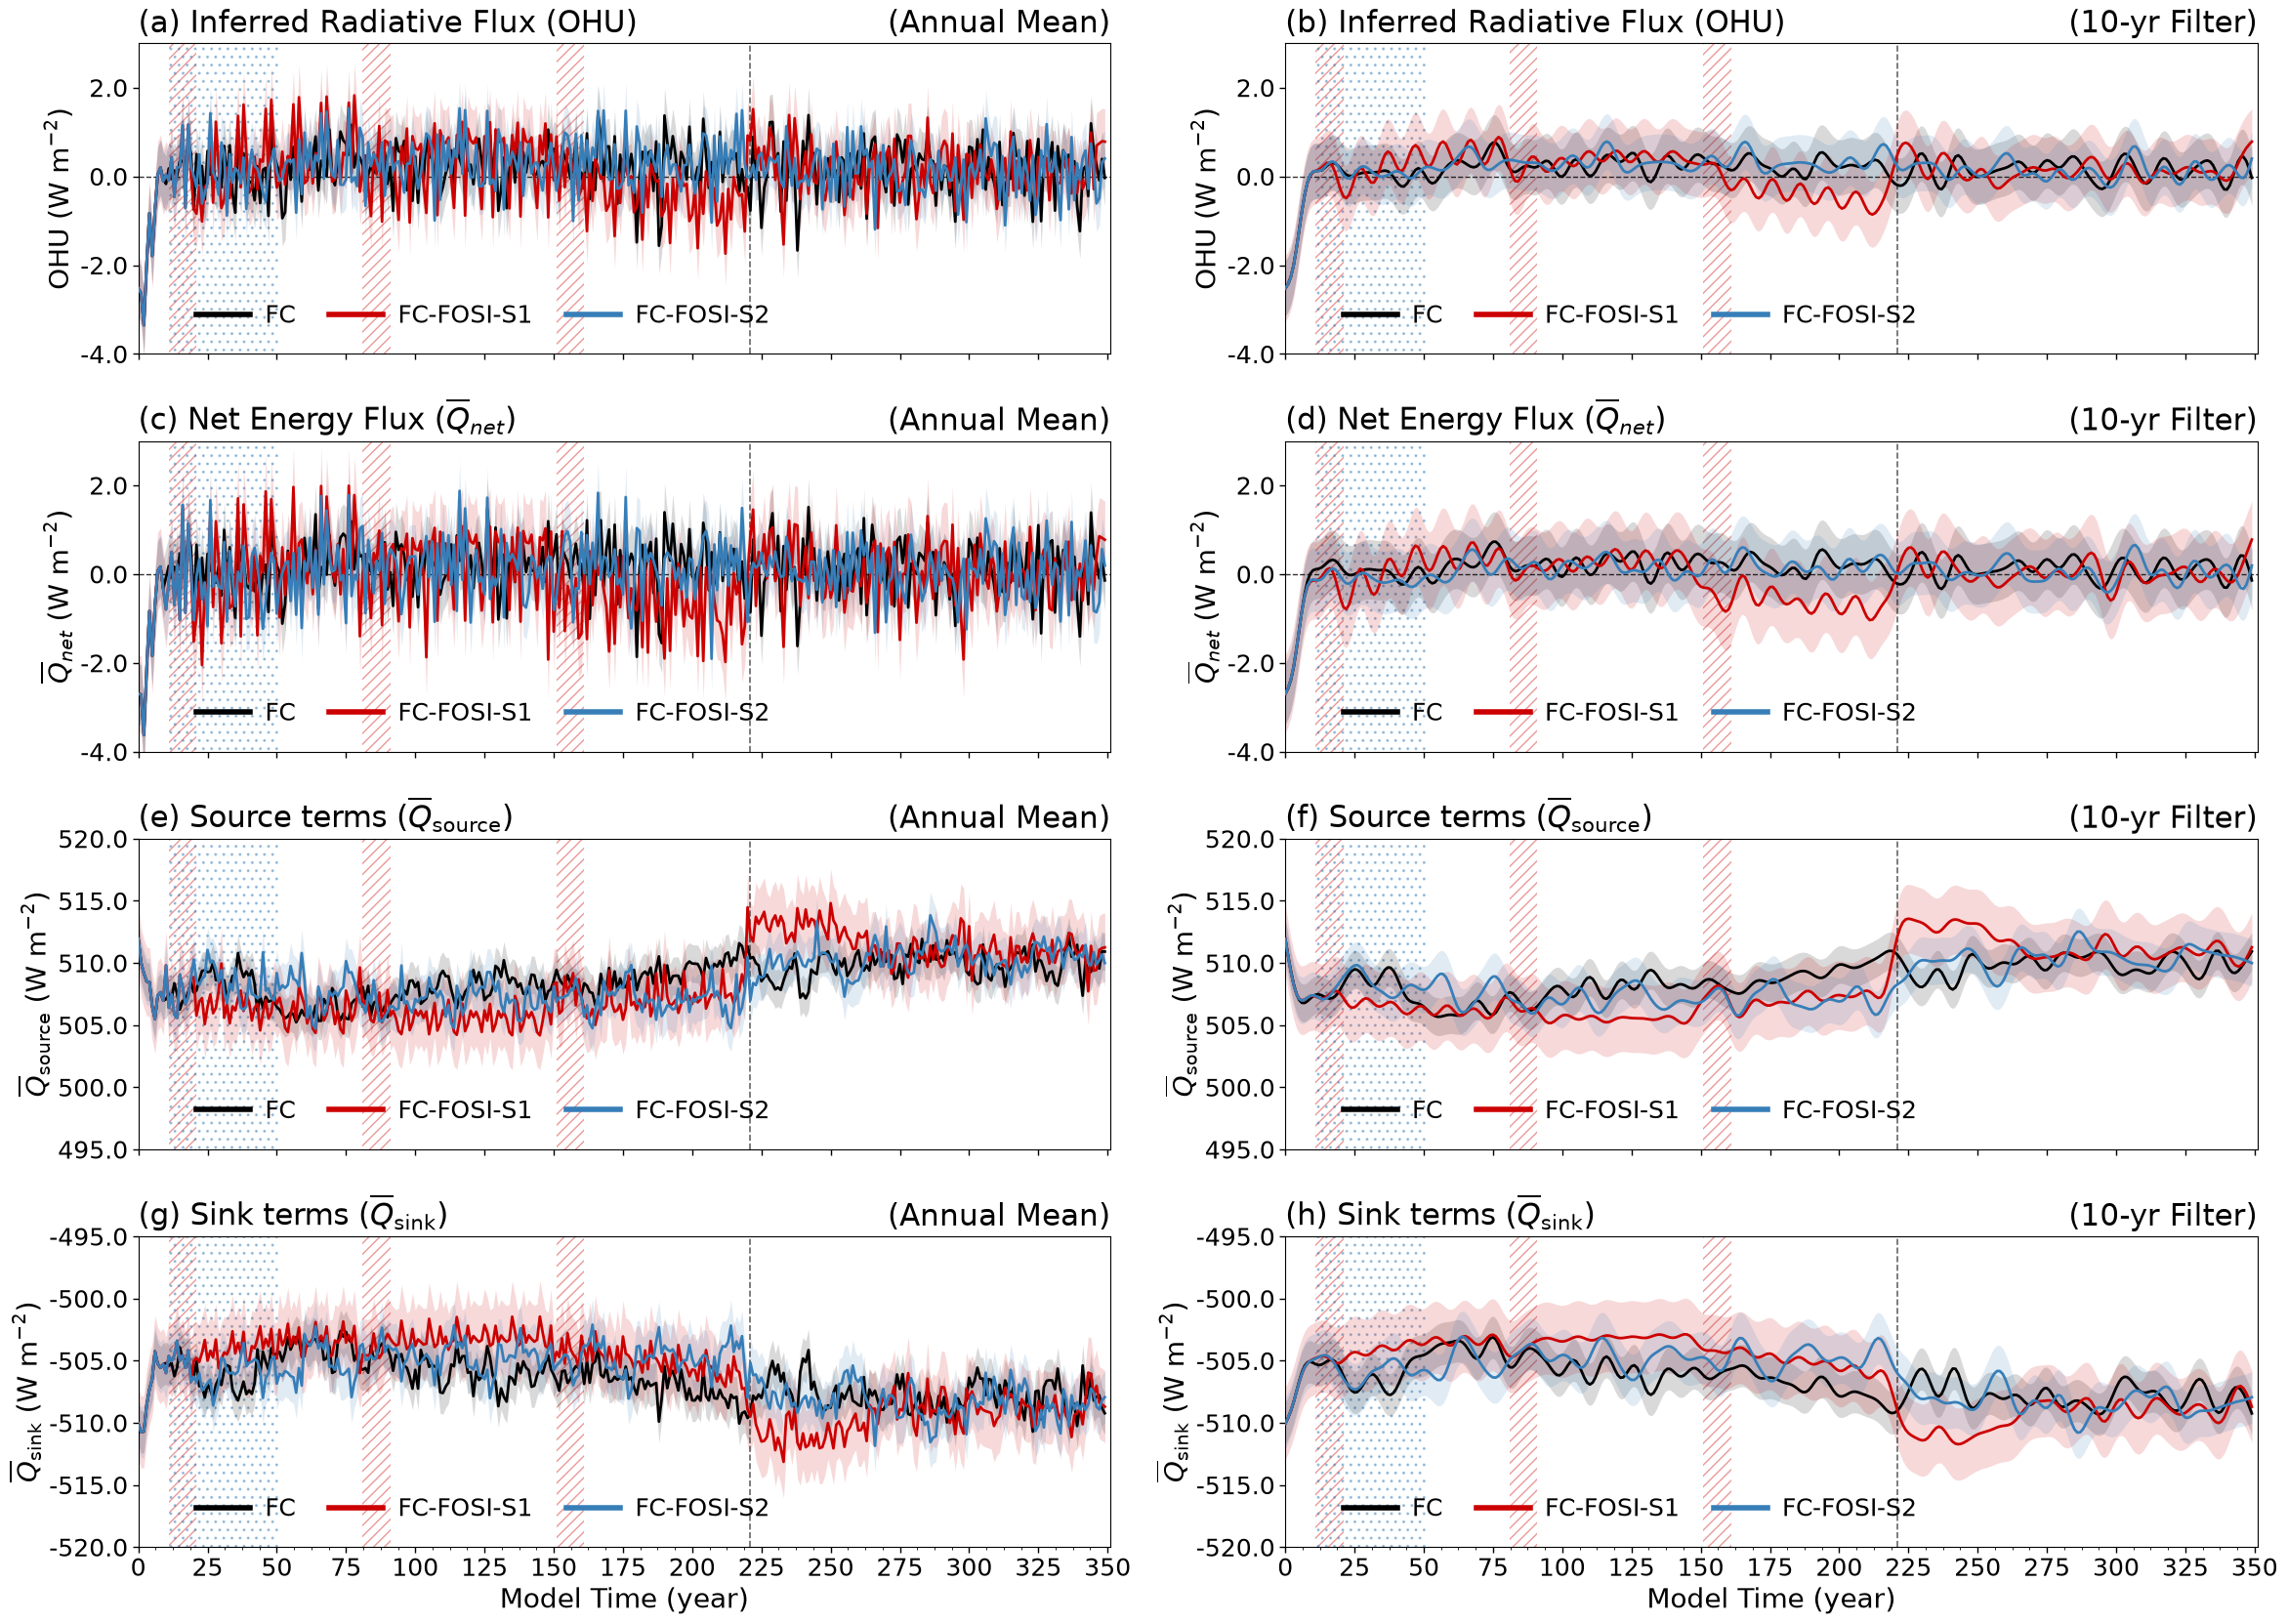

Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohu/ocean_ohu_diag_Global_ts_yr0001-0350.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohu


In [5]:
# ============================================================
# Collector
# ============================================================
collector = OHUFigureDataCollector(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    data_dir=data_dir,
    year_token=year_token,
    time_unit=time_unit,
    calendar=calendar,
    region_key=region_key,
    reg_dim=reg_dim,
    reg_var=reg_var,
    engine=engine,
    chunks=chunks,
    use_mfdataset=use_mfdataset,
    verbose=verbose,
)

if collect_figure_data:
    spec = OHUFigureExtractSpec(
        # ---- OHU side ----
        ohc_ts_base=ohc_ts_base,
        ohc_climo_len=ohc_clim_len,
        ohc_need_vars=ohc_need_vars,
        ohc_file_key=ohc_file_key,
        ohc_fdepth=ohc_fdepth,
        ohc_anomaly=ohc_anomaly,
        ohc_baseline_months=ohc_baseline_months,
        ohc_to_ZJ=ohc_to_ZJ,
        ohc_use_mask_in_volume=ohc_use_mask_in_volume,
        ohc_annual_mean=ohc_annual_mean,
        ohc_annual_weighted=ohc_annual_weighted,
        ohc_annual_drop_incomplete=ohc_annual_drop_incomplete,
        ohc_annual_min_days=ohc_annual_min_days,
        ohc_reassign_monthly_time=ohc_reassign_monthly_time,
        ohc_length_policy=ohc_length_policy,
        ohc_mpas_analysis=ohc_mpas_analysis,

        # ---- Flux side ----
        flux_ts_base=flux_ts_base,
        flux_climo_len=flux_clim_len,
        flux_need_vars=flux_need_vars,
        flux_need_base=flux_need_base,
        flux_annual_mean=extract_annual_mean,
        flux_annual_weighted=extract_annual_weighted,
        flux_per_area_vars=flux_per_area_vars,
        flux_mpas_analysis=flux_mpas_analysis,
    )

    plot_data = collector.collect(
        spec=spec,
        plot_vars=list(plot_info.keys()),
    )

    # Save TS data (exact plotted series)
    collector.save_per_exp(
        out_nc_base=out_ncb,
        plot_data=plot_data,
        plot_info=plot_info,
        freq="annual" if extract_annual_mean else "monthly",
        year_min_for_coords=year_min_plot,
        year_max_for_meta=year_max_plot,
        apply_scale=True,
        attrs={
            "region": region_key,
            "calendar": calendar,
            "ts_window_years": f"{year_min}-{year_max}",
            "figure_pdf": os.path.basename(out_pdf),
        },
    )
else:
    plot_data = collector.load_per_exp(
        out_nc_base=out_ncb,
        ts_var_keys=list(plot_info.keys()),
    )

print(plot_data.keys())

# ============================================================
# Plotting controls (convert monthly -> annual here)
# ============================================================
exp_order  = exp_tags
exp_labels = labels

plot_annual_mean = True
compute_anomaly = False
running_mean = False
running_mean_months = 12
use_filter = False
trend_years = 100
trend_unit = "per_decade"

var_list = ["OHU_0_bottom","Qnet", "Qsource", "Qsink"] #list(plot_info.keys())
nvars = len(var_list)

# ---- RAW vs FILTERED layout: each var is a row, 2 cols (raw | filtered) ----
nrows = nvars
ncols = 2
figsize = (28, 20) #(28, 4.8 * nrows)   # keep your style but scale with rows
fontsize = 22
step_yrs = 25
ref_yrs = [SWITCH_YEAR]

std_band   = True
std_center = "filtered"
std_source = "raw"
std_mode   = "global"
show_title = True
use_panel_labels = True
sha_alpha = 0.03
stats_format = "json"
constrained_layout = False
wspace = 0.18
hspace = 0.28

# IMPORTANT: filter must be enabled for right panel
use_filter = True
filt_cutoff_months = 120.0   # ~10-year cutoff if interpreting as months
filt_order = 4
filt_method = "pad"
edge_fix_points = 0
sharex=False
sharey=False

plotter = OHUDiagnosticsPlotter(
    year_min=year_min_plot,
    year_max=year_max_plot,
    annual_mean=plot_annual_mean,
    compute_anomaly=compute_anomaly,
    running_mean=running_mean,
    running_mean_months=running_mean_months,
    use_filter=use_filter,
    filt_cutoff_months=filt_cutoff_months,
    filt_order=filt_order,
    filt_method=filt_method,
    edge_fix_points=edge_fix_points,
    trend_years=trend_years,
    trend_unit=trend_unit,
)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=figsize,
    constrained_layout=constrained_layout,
    sharex=sharex,
    sharey=sharey,
)

fig.subplots_adjust(wspace=wspace, hspace=hspace)
axes = np.atleast_2d(axes)

# ---- preserve filter state (we'll toggle per panel) ----
_use_filter0 = bool(plotter.use_filter)
_butter_b0, _butter_a0 = plotter._butter_b, plotter._butter_a
try:
    for i, var_key in enumerate(var_list):
        axL = axes[i, 0]   # RAW
        axR = axes[i, 1]   # FILTERED

        vinfo = plot_info[var_key]

        # show xticks only on last row (both panels)
        show_xticks = (i == nvars - 1)
        show_ylabel = True

        panel_label_L = f"({chr(ord('a') + 2*i)})" if use_panel_labels else ""
        panel_label_R = f"({chr(ord('a') + 2*i + 1)})" if use_panel_labels else ""

        # legend only on top-left (clean, consistent)
        legend_L = "lower left" #if (i == 0) else None
        legend_R = "lower left" #None

        # ---- base request ----
        req_base = PlotRequest(
            key=var_key,
            vname=vinfo["short"],
            vunit=vinfo["unit"],
            scale=vinfo.get("scale", 1.0),
            ylim=vinfo.get("ylim", None),
            title=vinfo["label"],  # we'll override per panel
            y_label=fr"{vinfo['short']} ({vinfo['unit']})",
            show_xlabel=show_xticks,
            show_xticks=show_xticks,
            show_ylabel=show_ylabel,
            show_title=show_title,
        )

        # ---- IMPORTANT: unique stats base per variable & panel to avoid overwrite ----
        stats_base_var = f"{out_ncb}_{var_key}"

        # =========================
        # Left panel: RAW
        # =========================
        plotter.use_filter = False  # toggle OFF filter
        plotter._butter_b, plotter._butter_a = _butter_b0, _butter_a0  # keep as-is

        reqL = replace(req_base)
        ltstr = f"{vinfo['label']}"
        lrstr = "(Annual Mean)" if plotter.annual_mean else "(Monthly Mean)"
        reqL.title = (f"{ltstr}",f"{lrstr}")
        reqL.panel_label = panel_label_L
        reqL.legend_loc = legend_L

        _stats_raw = plotter.plot_on_axis(
            ax=axL,
            data=plot_data,
            var_key=var_key,
            exp_order=exp_order,
            exp_labels=exp_labels,
            colors=colors,
            req=reqL,
            fontsize=fontsize,
            step_yrs=step_yrs,
            ref_yrs=ref_yrs,
            std_band=std_band,
            std_center="raw",          # center band on plotted raw curve
            std_source=std_source,
            std_mode=std_mode,
            exp_shas=exp_shas,
            sha_alpha=sha_alpha,
            save_stats_base=f"{stats_base_var}_raw",
            stats_format=stats_format,
        )

        # =========================
        # Right panel: FILTERED
        # =========================
        plotter.use_filter = True   # toggle ON filter
        # (butter coeffs already prepared in __init__ because use_filter=True there)

        reqR = replace(req_base)
        cutoff_yrs = float(filt_cutoff_months) / 12.0 if plotter.annual_mean else float(filt_cutoff_months)
        ltstr = f"{vinfo['label']}"
        lrstr = f"({cutoff_yrs:g}-yr Filter)" if plotter.annual_mean else f"({filt_cutoff_months:g}-mo Filter)"
        reqR.title = (f"{ltstr}",f"{lrstr}")
        reqR.panel_label = panel_label_R
        reqR.legend_loc = legend_R

        _stats_filt = plotter.plot_on_axis(
            ax=axR,
            data=plot_data,
            var_key=var_key,
            exp_order=exp_order,
            exp_labels=exp_labels,
            colors=colors,
            req=reqR,
            fontsize=fontsize,
            step_yrs=step_yrs,
            ref_yrs=ref_yrs,
            std_band=std_band,
            std_center="filtered",     # center band on plotted filtered curve
            std_source=std_source,
            std_mode=std_mode,
            exp_shas=exp_shas,
            sha_alpha=sha_alpha,
            save_stats_base=f"{stats_base_var}_filt",
            stats_format=stats_format,
        )

    fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_pdf)

finally:
    # restore plotter state
    plotter.use_filter = _use_filter0
    plotter._butter_b, plotter._butter_a = _butter_b0, _butter_a0

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
